In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import r2_score
import os 
import glob
import math


In [118]:
class Test:
    def __init__(self, df):
        self.df = df.copy()  # Avoid modifying the original DataFrame
        self.id = df['participant_ID'].iloc[0]
        self.date = df['visit_date'].iloc[0]
        self.name = f"{self.id}_{self.date}"
        
        # Assign 'Stage' only for 'EXERCISE' phase, then fill NaN values with 0
        self.df['Stage'] = np.nan
        exercise_mask = self.df['Phase'] == 'EXERCISE'
        self.df.loc[exercise_mask, 'Stage'] = self.df[exercise_mask].groupby(['Speed', 'Grade']).ngroup() + 1
        self.df['Stage'].fillna(0, inplace=True)  # Ensure non-exercise rows have Stage 0
        
        # Convert 't' to timedelta and set it as index
        self.df['t'] = pd.to_timedelta(self.df['t'])
        self.df.set_index('t', inplace=True)
        
        self.lactate_df = self.prepare_lactate_df()
    
    def prepare_lactate_df(self):
        # Reset index to retrieve 't' column
        lactate_df = self.df.dropna(subset=['La-']).reset_index()
        lactate_df = lactate_df[['t', 'La-', 'Phase', 'Speed', 'Grade', 'Stage']]
        
        # Remove extreme lactate values (greater than 20)
        lactate_df = lactate_df[lactate_df['La-'] <= 20]
        
        # Apply logarithmic transformation, handling non-positive values
        lactate_df['log_lactate'] = np.log(lactate_df['La-'].replace(0, np.nan))
        lactate_df['log_speed'] = np.log(lactate_df['Speed'].replace(0, np.nan))
        
        return lactate_df


    def lactate_graph(self):
        # Separate logic for graphing
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        self.plot_lactate_reference(axes[0])
        self.plot_lactate_absolute(axes[1])
        plt.tight_layout()
        return plt

    def plot_lactate_reference(self, ax):
        ax.plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        ax.set_xlabel('Time')
        ax.set_ylabel('Lactate mmol/L')
        ax.set_title('Lactate vs Time Using Reference ' + self.name)
        ax.set_ylim(0, None)

        LT1_ref, LT2_ref, _, _ = self.lt_ref_vals()
        if LT1_ref:
            ax.axvline(x=LT1_ref, color='r', label='LT1')
        if LT2_ref:
            ax.axvline(x=LT2_ref, color='g', linestyle='--', label='LT2')

        ax.set_xticks(self.lactate_df['t'])
        ax.legend(loc='upper left')

    def plot_lactate_absolute(self, ax):
        ax.plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        ax.set_xlabel('Time')
        ax.set_ylabel('Lactate mmol/L')
        ax.set_title('Lactate vs Time Using Absolute ' + self.name)
        ax.set_ylim(0, None)

        LT1_abs, LT2_abs, _, _ = self.lt_abs_vals()
        ax.axhline(y=2, color='r', label='Threshold 2 mmol/L')
        ax.axhline(y=4, color='g', linestyle='--', label='Threshold 4 mmol/L')

        ax.set_xticks(self.lactate_df['t'])
        ax.legend(loc='upper left')

    def lt_ref_vals(self):
        lt1ref_index = (self.lactate_df['La-'].diff() >= 0.5)
        lt2ref_index = (self.lactate_df['La-'].diff() >= 1)
        LT1ref = self.lactate_df.loc[lt1ref_index.idxmax(), 'La-'] if lt1ref_index.any() else None
        LT2ref = self.lactate_df.loc[lt2ref_index.idxmax(), 'La-'] if lt2ref_index.any() else None
        LT1ref_speed = self.lactate_df.loc[lt1ref_index.idxmax(), 'Speed'] if lt1ref_index.any() else None
        LT2ref_speed = self.lactate_df.loc[lt2ref_index.idxmax(), 'Speed'] if lt2ref_index.any() else None
        results = {"LT1_ref":LT1ref, "LT2_ref":LT2ref, "LT1ref_speed":LT1ref_speed, "LT2ref_speed":LT2ref_speed}
        return results

    def lt_abs_vals(self):
        lt1abs_index = (self.lactate_df['La-'] >= 2)
        lt2abs_index = (self.lactate_df['La-'] >= 4)
        
        LT1abs = self.lactate_df.loc[lt1abs_index.idxmax(), 'La-'] if lt1abs_index.any() else None
        LT2abs = self.lactate_df.loc[lt2abs_index.idxmax(), 'La-'] if lt2abs_index.any() else None
        LT1abs_speed = self.lactate_df.loc[lt1abs_index.idxmax(), 'Speed'] if lt1abs_index.any() else None
        LT2abs_speed = self.lactate_df.loc[lt2abs_index.idxmax(), 'Speed'] if lt2abs_index.any() else None
        
        results = {
            "LT1_abs": LT1abs, 
            "LT2_abs": LT2abs, 
            "LT1abs_speed": LT1abs_speed, 
            "LT2abs_speed": LT2abs_speed
        }
        return results

    def heart_rate_graph(self):
        fig, ax1 = plt.subplots(figsize=(10, 5))
        exercise_df = self.df[self.df['Phase'] == 'EXERCISE']
        rolling_mean = exercise_df['VO2'].rolling(window=5).mean()

        ax1.plot(exercise_df['t'], rolling_mean, color='blue', label='Heart Rate')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Heart Rate')
        ax1.set_title('Heart Rate and Speed Over Time')
        ax1.grid(True)

        stage_changes = exercise_df[exercise_df['Stage'] != exercise_df['Stage'].shift()]
        stage_times = stage_changes['t']

        for time in stage_times:
            ax1.axvline(x=time, color='red', linestyle='--', alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(exercise_df['t'], exercise_df['Speed'], color='black', linestyle='-', alpha=0.6, label='Speed')
        ax2.set_ylabel('Speed (mph)', color='black')
        ax2.tick_params(axis='y', labelcolor='black')

        lactate_times = self.lactate_df['t'][:-3]
        ax1.set_xticks(lactate_times)

        fig.tight_layout()
        plt.show()

    
    def linear_regression(self, x, y):
        """Perform linear regression and return slope, intercept, and r-value."""
        slope, intercept, r_value, _, _ = linregress(x, y)
        return slope, intercept, r_value
    def find_best_split(self, x, y):
        """Finds the best split point for two linear regression fits with one overlapping point and computes the best R²"""
        best_r2_combined = -np.inf
        best_params = None
        
        if len(x) == 4:
            split_points = [2]  # Only one valid split at index 2
        else:
            split_points = range(2, len(x) - 1)  # Ensure one overlapping point
        
        for split in split_points:  
            x_first, y_first = x[:split + 1], y[:split + 1]  # Include split point in first segment
            x_last, y_last = x[split:], y[split:]  # Include split point in second segment

            # Perform linear regression
            slope_first, intercept_first = np.polyfit(x_first, y_first, 1)
            slope_last, intercept_last = np.polyfit(x_last, y_last, 1)

            # Compute intersection point
            x_intersect, y_intersect = self.compute_intersection(slope_first, intercept_first, slope_last, intercept_last)

            # Predict values for R² calculation
            y_pred_first = slope_first * x_first + intercept_first
            y_pred_last = slope_last * x_last + intercept_last

            # Calculate R² values
            r2_first = r2_score(y_first, y_pred_first)
            r2_last = r2_score(y_last, y_pred_last)

            # Compute weighted R²
            r2_combined = ((len(x_first) * r2_first) + (len(x_last) * r2_last)) / (len(x_first) + len(x_last))

            # Track best split
            if r2_combined > best_r2_combined:
                best_r2_combined = r2_combined
                best_params = (slope_first, intercept_first, slope_last, intercept_last, x_intersect, y_intersect, r2_first, r2_last)
        
        return best_params, best_r2_combined

    def compute_intersection(self, m1, b1, m2, b2):
        """Finds intersection of two lines y = m1*x + b1 and y = m2*x + b2"""
        if m1 == m2:
            return None, None  # Parallel lines, no intersection
        x_intersect = (b2 - b1) / (m1 - m2)
        y_intersect = m1 * x_intersect + b1
        return x_intersect, y_intersect

    def plot_results(self, ax, x, y, params, title, xlabel, ylabel):
        slope_first, intercept_first, slope_last, intercept_last, x_intersect, y_intersect, r2_first, r2_last = params

        ax.scatter(x, y, color='black', label='Data')

        # Define x-range for the full span of the graph
        x_min, x_max = min(x), max(x)
        x_range = np.linspace(x_min, x_max, 100)  # Generate a smooth range of x-values

        # Compute y-values for the extended regression lines
        y_first = slope_first * x_range + intercept_first
        y_last = slope_last * x_range + intercept_last

        # Plot the regression lines
        ax.plot(x_range, y_first, 'r-', label=f'Line 1 (R²={r2_first:.2f})')
        ax.plot(x_range, y_last, 'g-', label=f'Line 2 (R²={r2_last:.2f})')

        # Plot the intersection point
        ax.scatter(x_intersect, y_intersect, color='blue', zorder=3, label='Intersection')

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        ax.grid(True)

        # Ensure y-axis starts at 0
        ax.set_ylim(bottom=0)

    def lactate_log_graph(self):
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        data_dict = self.lt_log_semilog_vals()
        
            

    def lt_log_semilog(self, plot=False):
        """Creates LT1 (log-log) and LT2 (semi-log) plots with best two-segment regression fits and intersections"""
        # === Prepare Data ===
        filtered_df = self.lactate_df.drop_duplicates(subset='Speed', keep='first')
        filtered_df = filtered_df[(filtered_df['Speed'] > 0) & (filtered_df['La-'] > 0)]

        log_speed = np.log(filtered_df['Speed'])
        log_lactate = np.log(filtered_df['La-'])
        speed = filtered_df['Speed']

        # === LT1: Log Speed vs Log Lactate ===
        best_params_lt1, best_r2_combined_lt1 = self.find_best_split(log_speed, log_lactate)
        if best_params_lt1:
            x_intersect_lt1, y_intersect_lt1 = best_params_lt1[4:6]
            lt1_log = math.exp(y_intersect_lt1)
            lt1_log_speed = math.exp(x_intersect_lt1)
            lt1_log_r2 = best_r2_combined_lt1
        else:
            lt1_log = None
            lt1_log_speed = None
            lt1_log_r2 = None
            
        #self.plot_results(axs[0], log_speed, log_lactate, best_params_lt1, 
         #                 'LT1: Log Speed vs Log Lactate', 'Log Speed', 'Log Lactate')

        best_params_lt2, best_r2_combined_lt2 = self.find_best_split(speed, log_lactate)
        if best_params_lt2:
            x_intersect_lt2, y_intersect_lt2 = best_params_lt2[4:6]
            lt2_semilog = x_intersect_lt2
            lt2_semilog_speed = math.exp(y_intersect_lt2)
            lt2_semi_log_r2 = best_r2_combined_lt2
        else:
            lt2_semilog = None
            lt2_semilog_speed = None
            lt2_semi_log_r2 = None

        #self.plot_results(axs[1], speed, log_lactate, best_params_lt2, 
        #                  'LT2: Speed vs Log Lactate', 'Speed', 'Log Lactate')
        if plot:
            fig, axs = plt.subplots(1, 2, figsize=(12, 5))
            if best_params_lt1:
                self.plot_results(axs[0], log_speed, log_lactate, best_params_lt1, 'LT1: Log Speed vs Log Lactate', 'Log Speed', 'Log Lactate')
            if best_params_lt2:
                self.plot_results(axs[1], speed, log_lactate, best_params_lt2, 'LT2: Speed vs Log Lactate', 'Speed', 'Log Lactate')
            plt.tight_layout()
            plt.show()
        return {
            "LT1_log":  lt1_log,
            "LT1_log_speed": lt1_log_speed,
            "LT1_log_r2": lt1_log_r2,
            "LT2_semilog": lt2_semilog, 
            "LT2_semilog_speed": lt2_semilog_speed,
            "LT2_semi_log_r2": lt2_semi_log_r2
        } 
    def aerobic_1(self):
        vo2 = self.df['VO2']
        vco2 = self.df['VCO2']
        
        # Define an initial split index to separate the two regression regions
        split_index = len(vo2) // 2
        
        # Function to find the optimal intersection point
        best_index = split_index
        min_error = float('inf')
        
        for i in range(10, len(vo2) - 10):  # Ensure enough points for both regressions
            slope1, intercept1, _, _, _ = linregress(vo2[:i], vco2[:i])
            slope2, intercept2, _, _, _ = linregress(vo2[i:], vco2[i:])
            
            if slope1 < 1 and slope2 >= 1:  # Condition for V-slope method
                error = np.sum((vco2[:i] - (slope1 * vo2[:i] + intercept1))**2) + \
                        np.sum((vco2[i:] - (slope2 * vo2[i:] + intercept2))**2)
                if error < min_error:
                    min_error = error
                    best_index = i
        
        # Compute best fit lines
        slope1, intercept1, _, _, _ = linregress(vo2[:best_index], vco2[:best_index])
        slope2, intercept2, _, _, _ = linregress(vo2[best_index:], vco2[best_index:])
        
        # Intersection point
        vo2_threshold = (intercept2 - intercept1) / (slope1 - slope2)
        vco2_threshold = slope1 * vo2_threshold + intercept1
        
        # Create plot
        fig, ax = plt.subplots(figsize=(8,6))
        ax.scatter(vo2, vco2, label='Data', color='lightgray')
        ax.plot(vo2[:best_index], slope1 * vo2[:best_index] + intercept1, 'b', label='Slope < 1')
        ax.plot(vo2[best_index:], slope2 * vo2[best_index:] + intercept2, 'r', label='Slope ≥ 1')
        ax.scatter(vo2_threshold, vco2_threshold, color='black', zorder=3, label='Intersection Point')
        
        ax.set_xlabel('VO2 (L/min)')
        ax.set_ylabel('VCO2 (L/min)')
        ax.set_title('V-Slope Method for Aerobic Threshold')
        ax.set_xlim(0, None)
        ax.set_ylim(0, None)
        ax.legend()
        ax.grid()
        
        
        return fig, vo2_threshold, vco2_threshold
    def aerobic_anaerobic_2(self):
            # Apply rolling mean with a 5-second window
        PetO2 = self.df['PetO2'].rolling('5s', min_periods=1).mean()
        PetCO2 = self.df['PetCO2'].rolling('5s', min_periods=1).mean()
        
        # Convert time index to total seconds
        time = self.df.index.total_seconds()
        # Identify nadir: Minimum PetO2 value
        nadir_index = PetO2.idxmin()
        print(nadir_index)
        if pd.isna(nadir_index) or nadir_index not in self.df.index:
            raise ValueError("nadir_index is NaN or not in DataFrame index")

        nadir_time = self.df.index[self.df.index.get_loc(nadir_index)]  # Safer method to get position
        nadir_value = PetO2[nadir_index]

        # Find the first rise after nadir while PetCO2 is constant or increasing
        rise_index = None

        nadir_seconds = nadir_time.total_seconds()  # Convert Timedelta to seconds
        end_seconds = self.df.index[-1].total_seconds()

        for i in np.arange(nadir_seconds + 1, end_seconds, 1):  # Loop in seconds
            i_td = pd.Timedelta(seconds=i)  # Convert back to Timedelta
            if i_td in PetCO2.index and PetCO2.loc[i_td] >= PetCO2.loc[i_td - pd.Timedelta(seconds=1)] and PetO2.loc[i_td] > nadir_value:
                rise_index = i_td
                break

        # Compute the first derivative (rate of change)
        dPetCO2_dt = np.gradient(PetCO2, time)

        # Compute the second derivative (change in rate)
        d2PetCO2_dt2 = np.gradient(dPetCO2_dt, time)

        # Find the deflection point where the second derivative changes significantly
        deflection_index = np.argmax(np.abs(d2PetCO2_dt2))  # Max absolute change
        deflection_time = time[deflection_index]
        deflection_value = PetCO2.iloc[deflection_index]

        # Print results
        print(f"Deflection point found at time {deflection_time} sec with PetCO2 = {deflection_value}")

        if rise_index is not None:
            rise_time = rise_index.total_seconds()
            rise_PetO2 = PetO2[rise_index]
            rise_PetCO2 = PetCO2[rise_index]
            print(f"First rise after nadir found at time {rise_time} sec with PetO2 = {rise_PetO2} and PetCO2 = {rise_PetCO2}")
        else:
            print("No first rise after nadir found.")

        # Plot PetO2 and PetCO2
        fig, ax1 = plt.subplots(figsize=(8, 6))

        ax1.plot(time, PetO2, color='b', label='PetO2', zorder=2)
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('PetO2 (L/min)', color='b')
        ax1.tick_params(axis='y', labelcolor='b')

        ax2 = ax1.twinx()
        ax2.plot(time, PetCO2, color='r', label='PetCO2', zorder=1)
        ax2.set_ylabel('PetCO2 (L/min)', color='r')
        ax2.tick_params(axis='y', labelcolor='r')

        # Mark the nadir, first rise, and deflection points
        ax1.scatter(nadir_index.total_seconds(), nadir_value, color='black', zorder=3, label='Nadir')
        if rise_index is not None:
            ax1.scatter(rise_time, rise_PetO2, color='green', zorder=3, label='First Rise')
        ax2.scatter(deflection_time, deflection_value, color='purple', zorder=3, label='Deflection Point')

        fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
        ax1.grid(True)
        plt.title('PetO2 and PetCO2 vs. Time')
        plt.show()

        return nadir_index, nadir_value, rise_index, rise_time, rise_PetO2, rise_PetCO2, deflection_index, deflection_time, deflection_value

In [120]:
df = pd.read_csv('visit_data/TR000105_20220207_visit_data.csv')
test = Test(df)
test.aerobic_anaerobic_2()

0 days 00:15:13


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_18537/11369000.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df['Stage'].fillna(0, inplace=True)  # Ensure non-exercise rows have Stage 0


KeyError: Timedelta('0 days 00:15:14')

In [59]:
path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))

folder_name = "vo2_vco2_graphs"

for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_name = test.name  # Assuming each test has a unique name
    try:
        fig, vo2_threshold, vco2_threshold = test.aerobic_1()  # Correct unpacking
        fig.savefig(f'{folder_name}/{test_name}_aerobic_1.png')
        plt.close(fig)  # Free memory
        
        print(f"{test_name}: Aerobic 1 threshold: {vo2_threshold:.2f} L/min, {vco2_threshold:.2f} L/min")
    except Exception as e:
        print(f"Error processing {test_name}: {e}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


TR000105_20220207: Aerobic 1 threshold: -1382.24 L/min, -1517.95 L/min


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


TR000106_20220420: Aerobic 1 threshold: -339.70 L/min, -568.94 L/min


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


...

TR000101_20220331: Aerobic 1 threshold: -679.88 L/min, -850.67 L/min


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


TR000107_20220805: Aerobic 1 threshold: -2307.16 L/min, -2439.53 L/min


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


TR000109_20220518: Aerobic 1 threshold: -628.40 L/min, -741.27 L/min


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


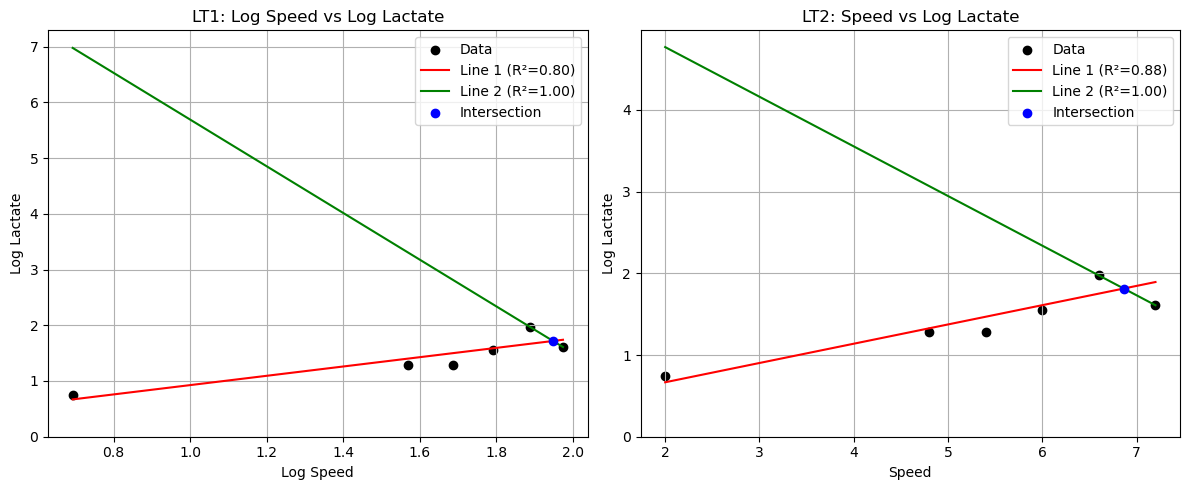

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


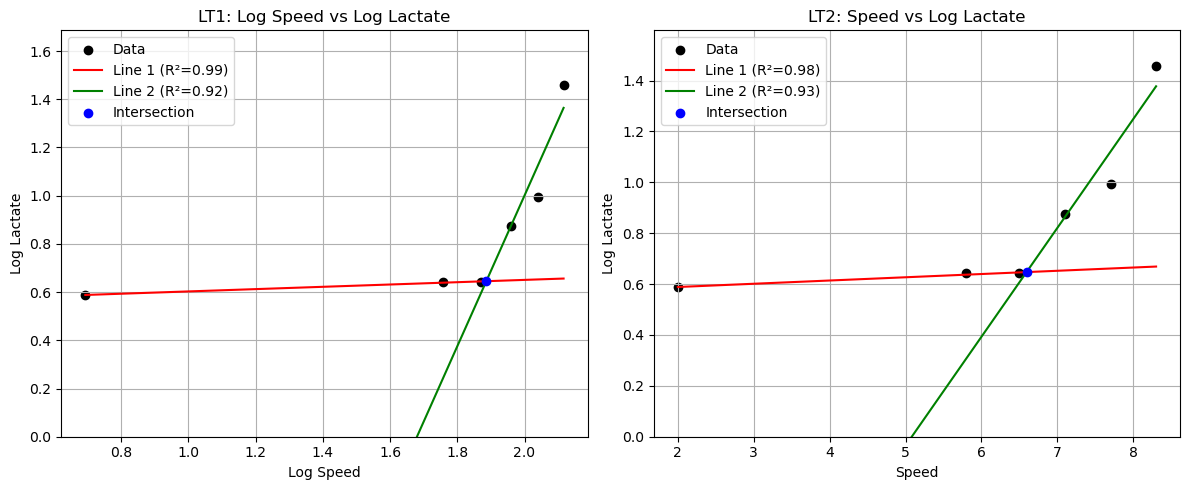

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


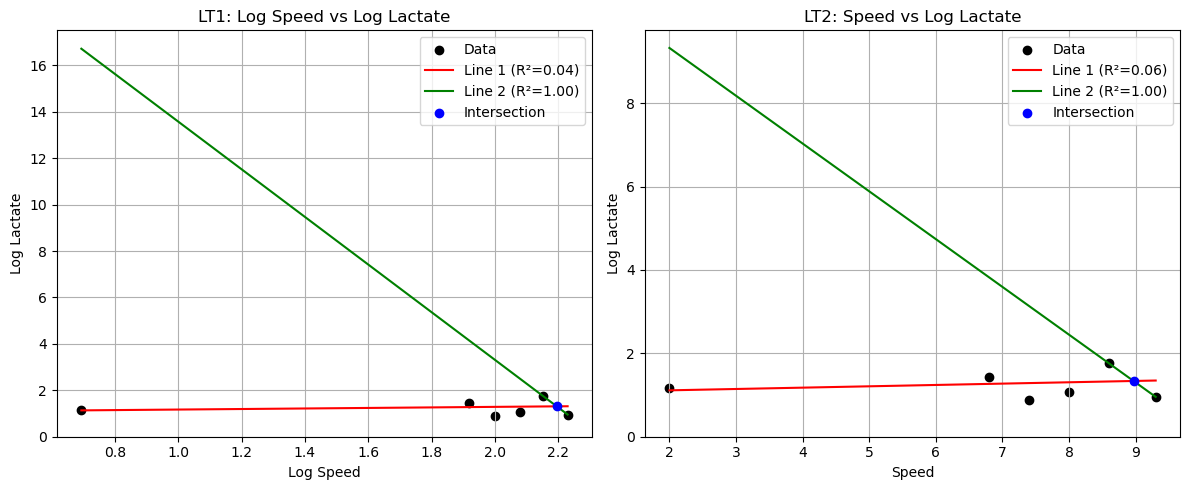

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


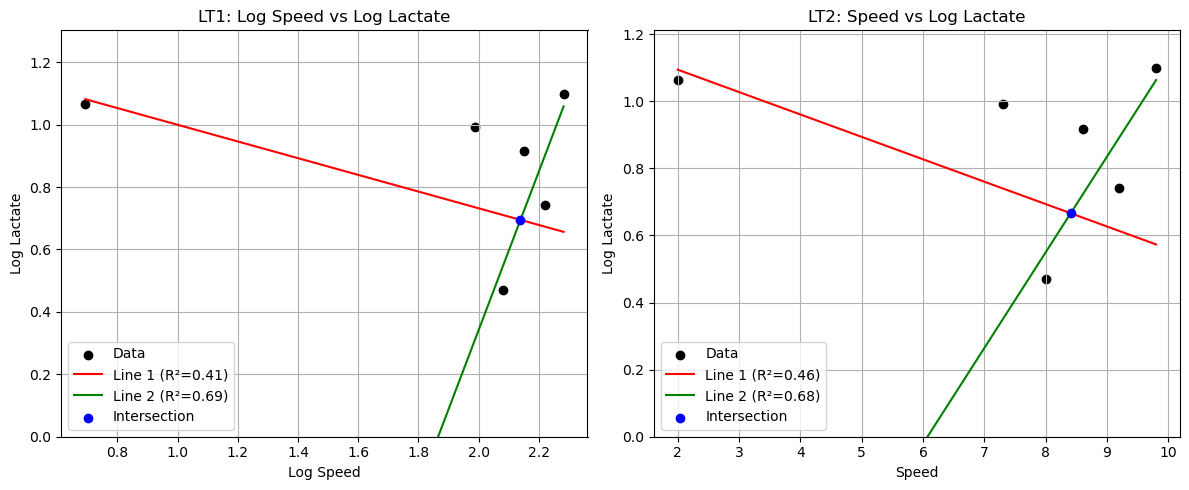

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


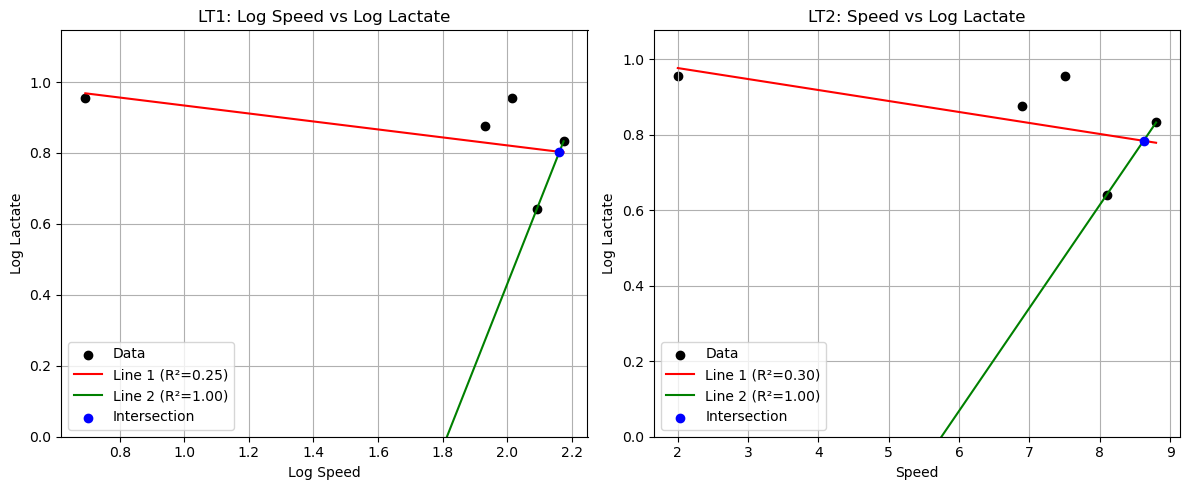

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


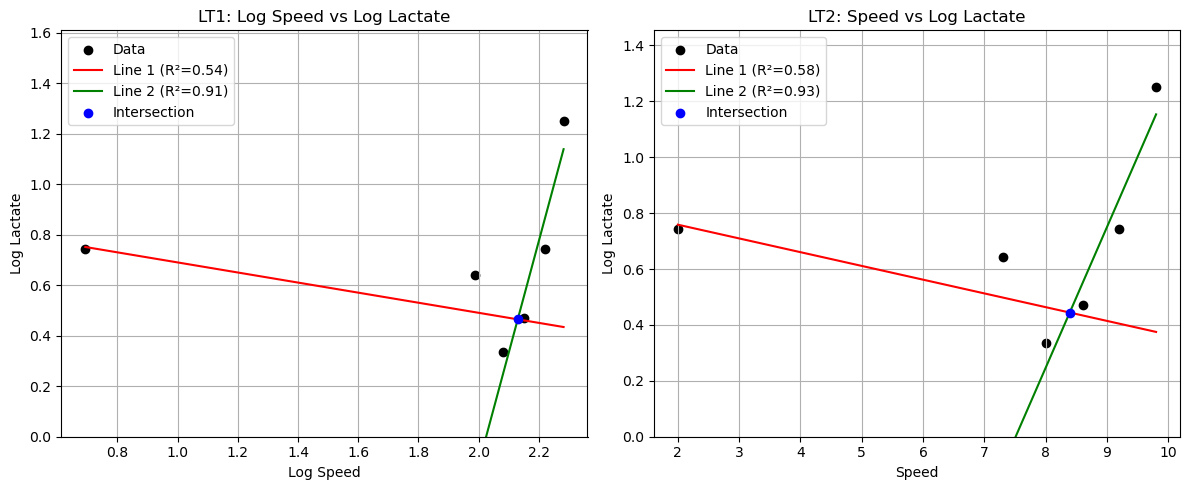

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


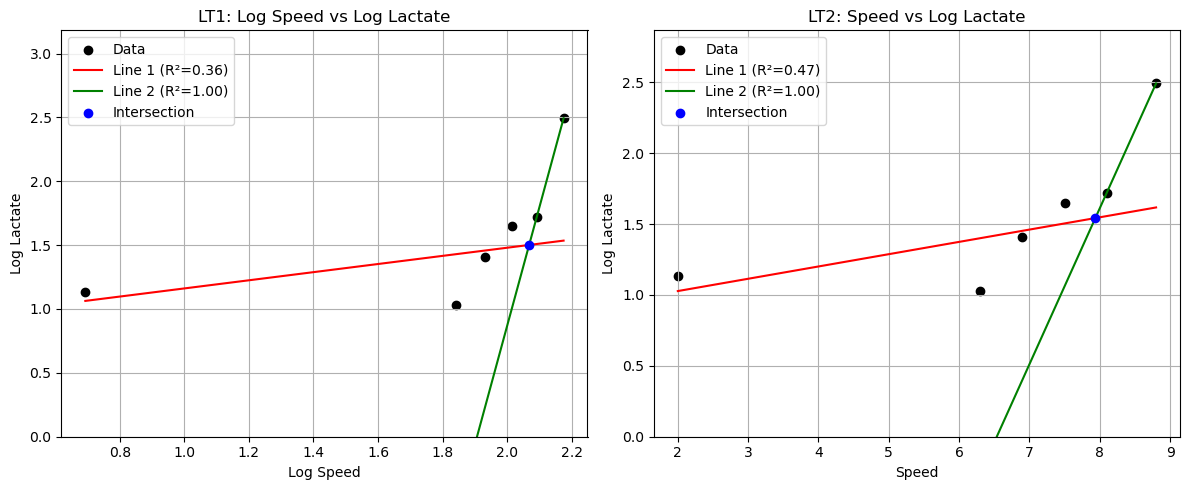

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


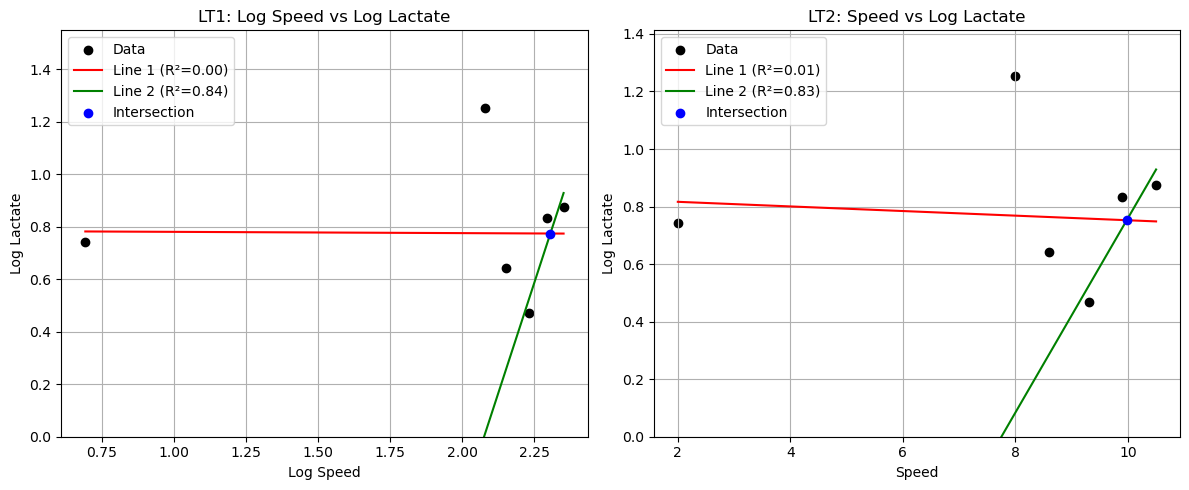

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


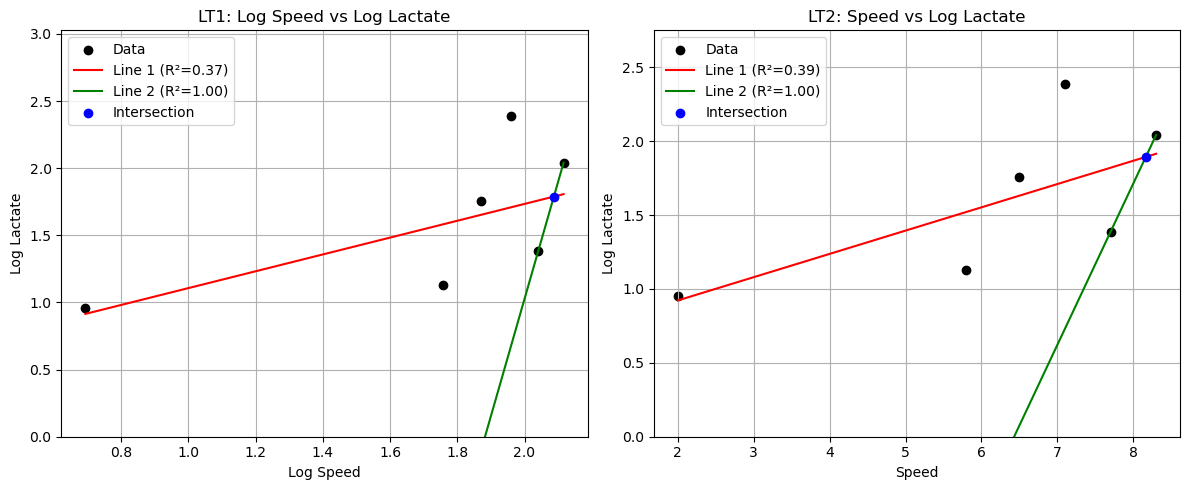

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


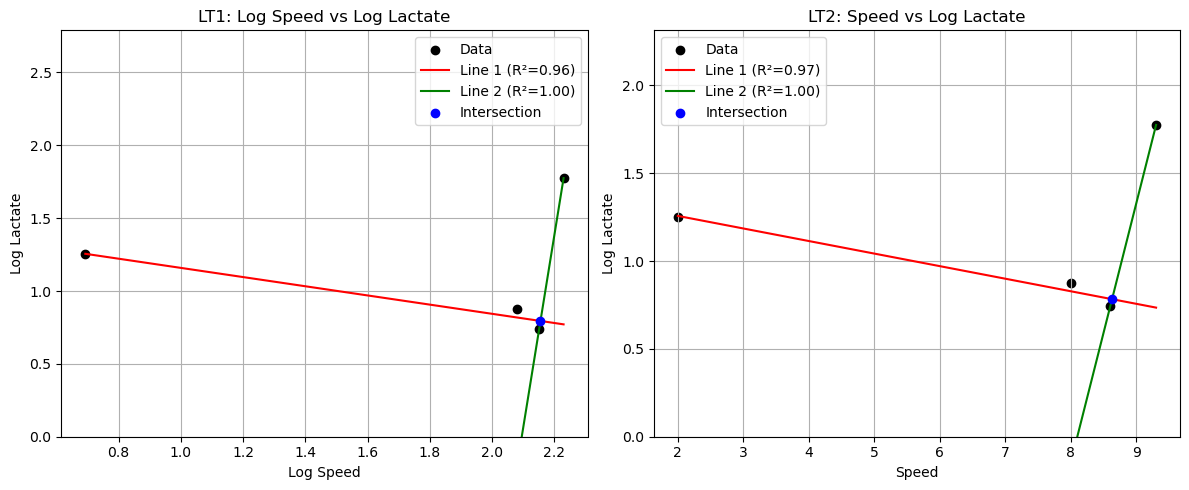

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


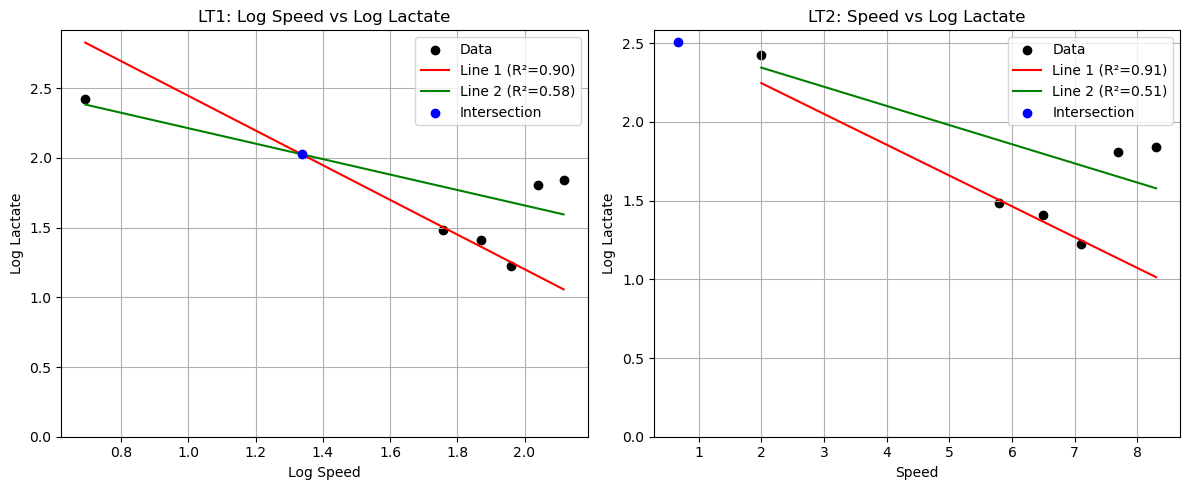

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


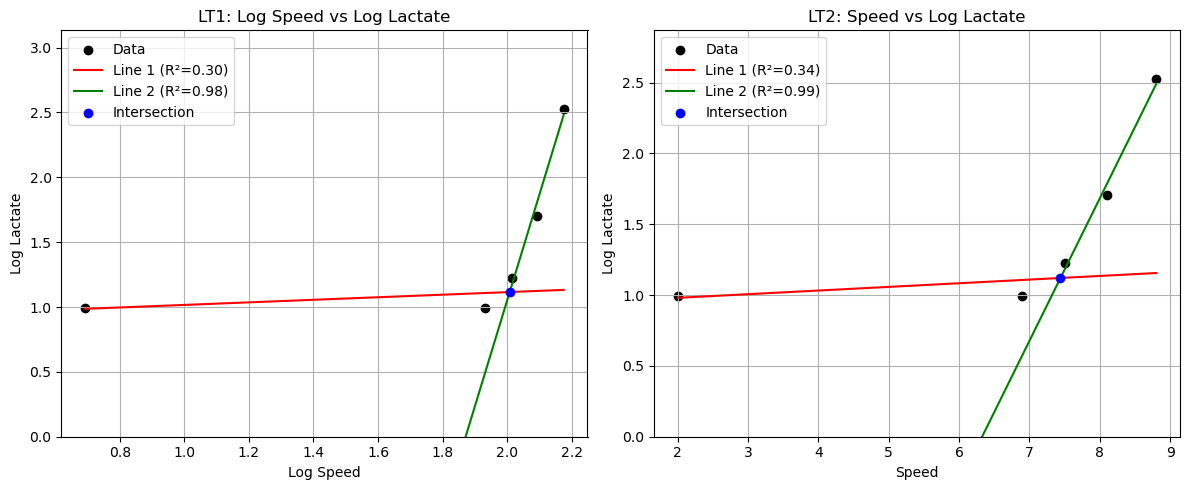

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


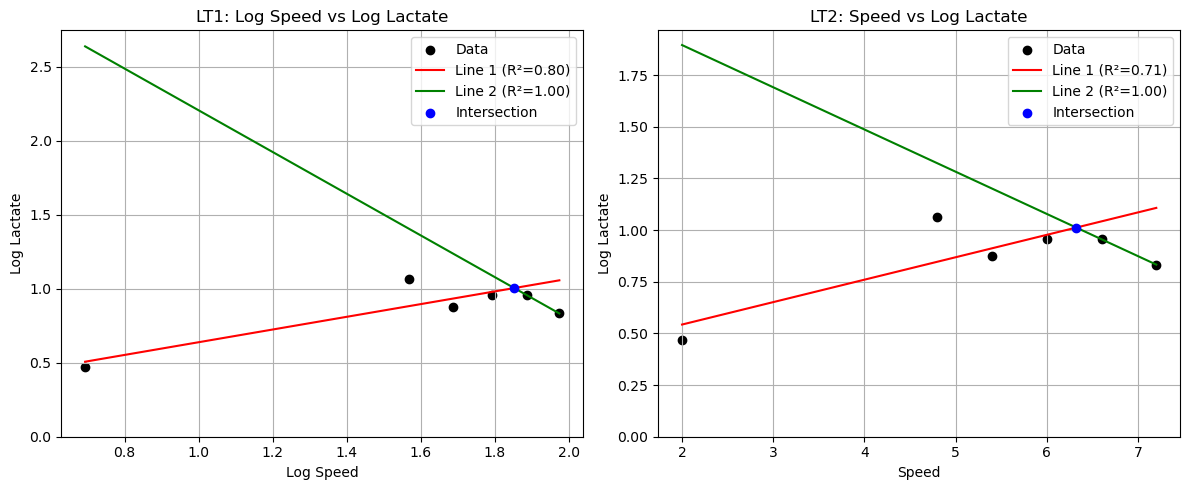

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


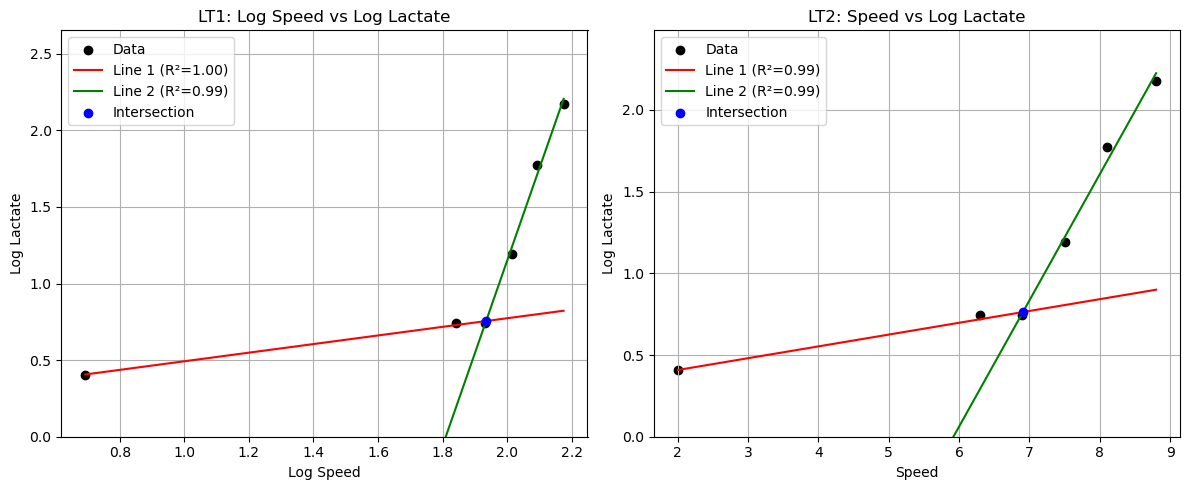

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


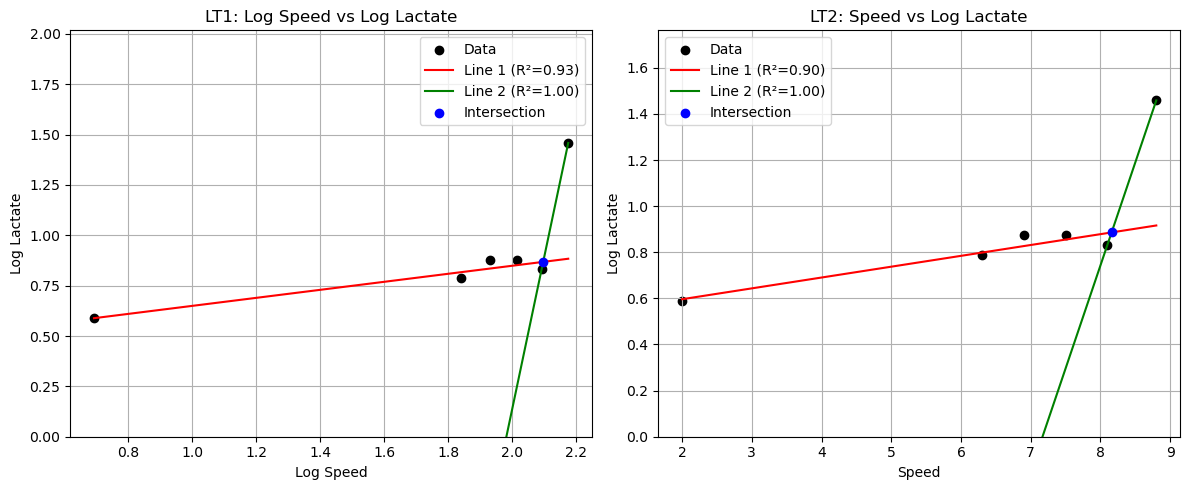

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


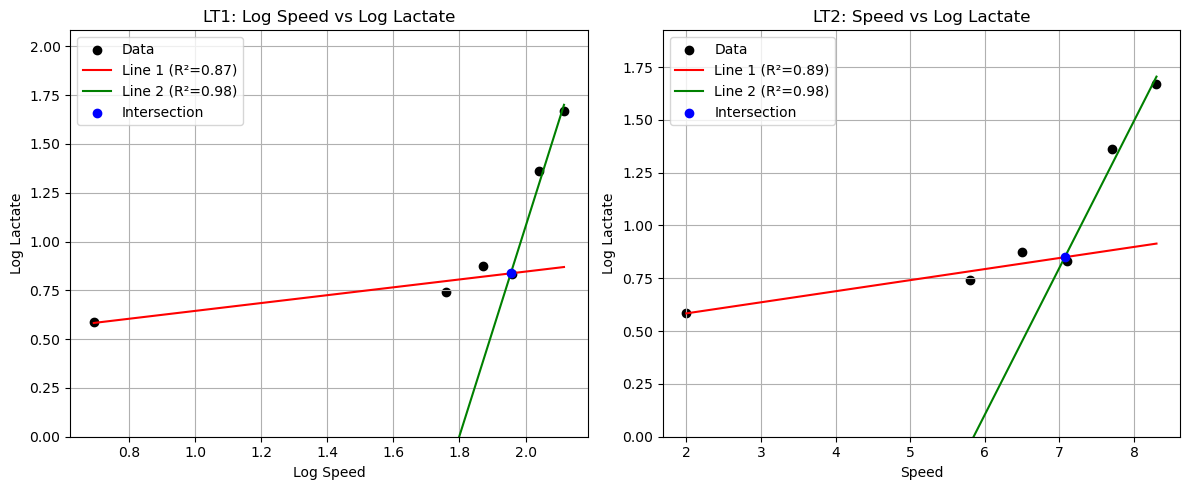

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


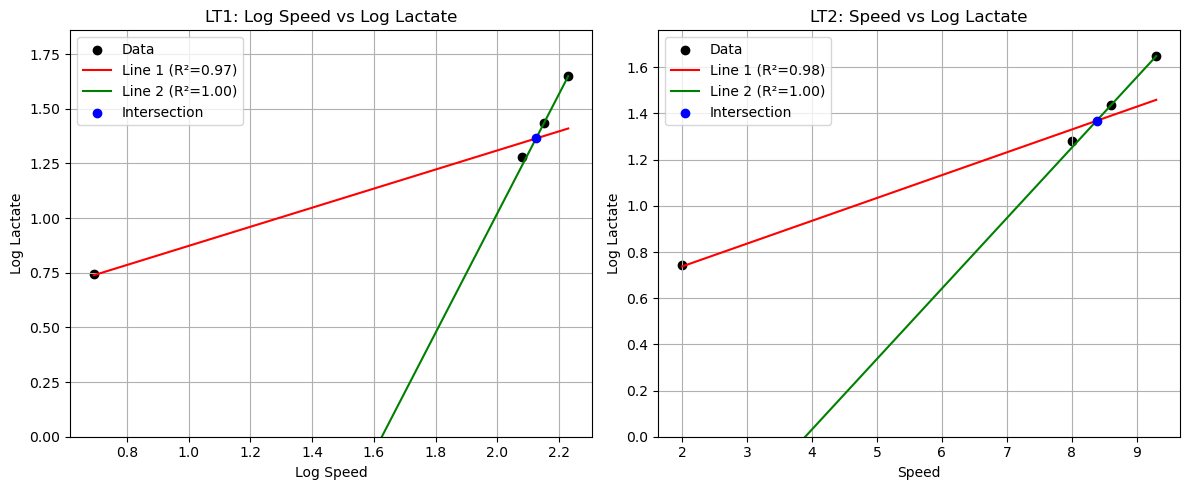

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


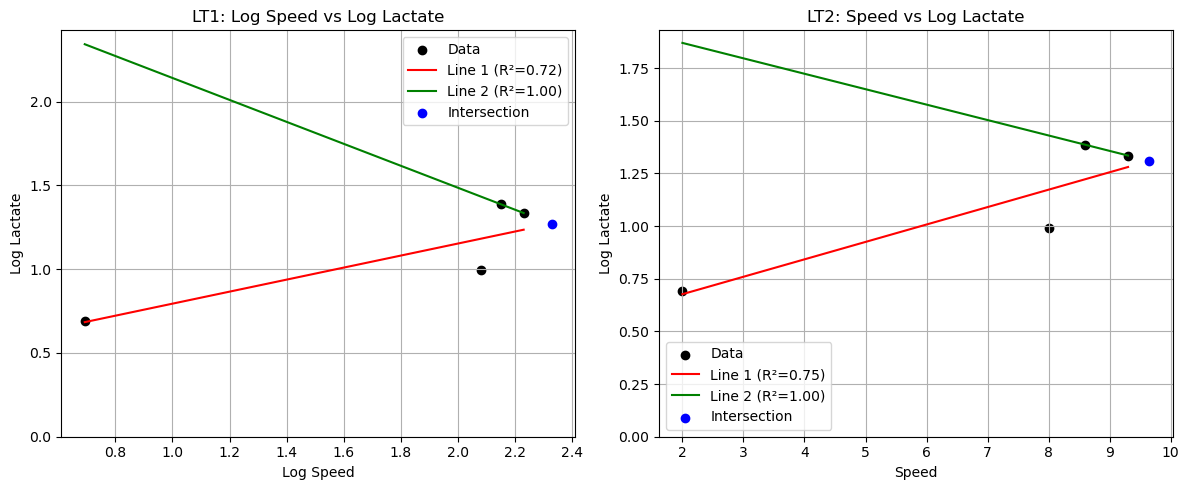

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


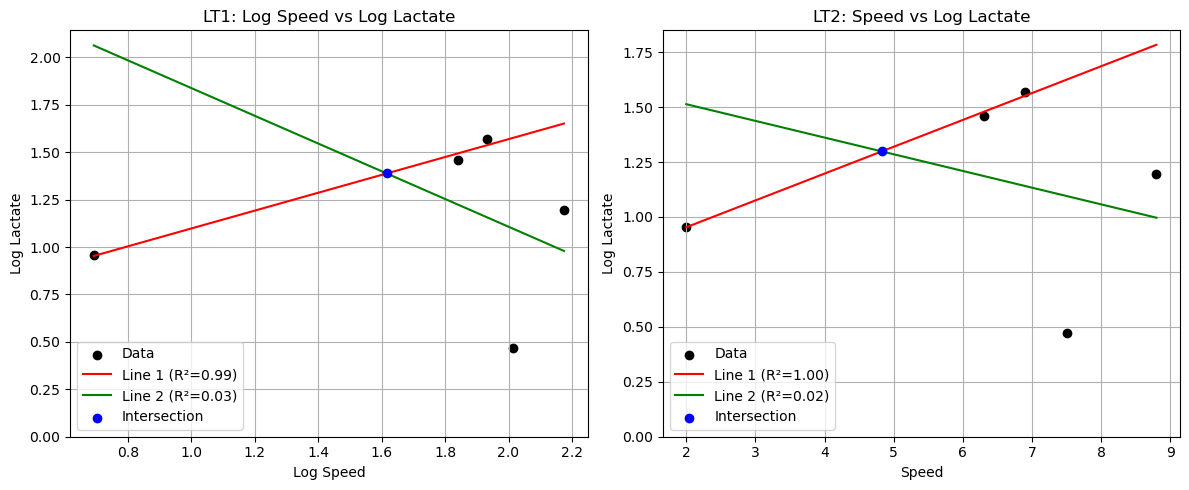

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


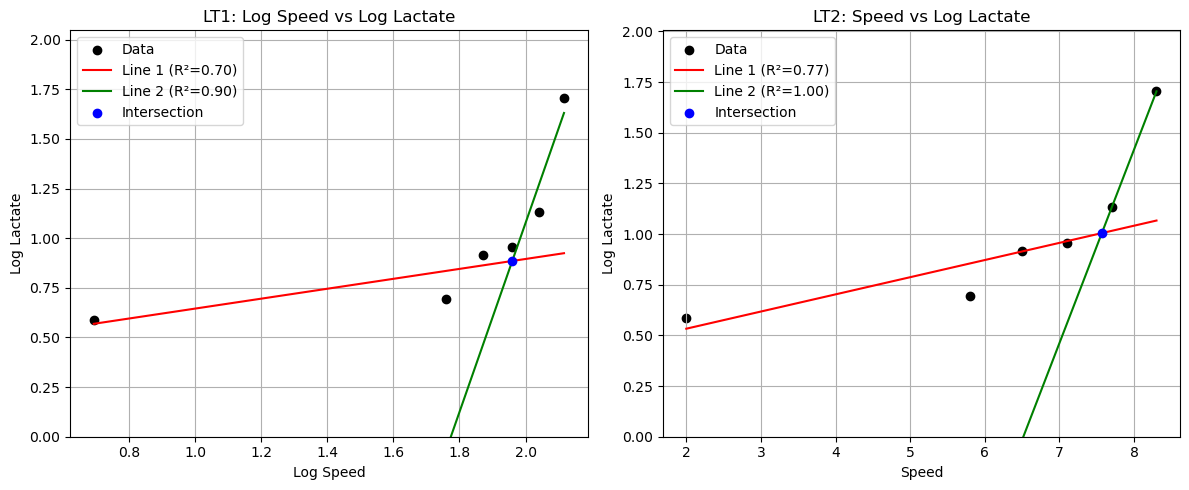

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


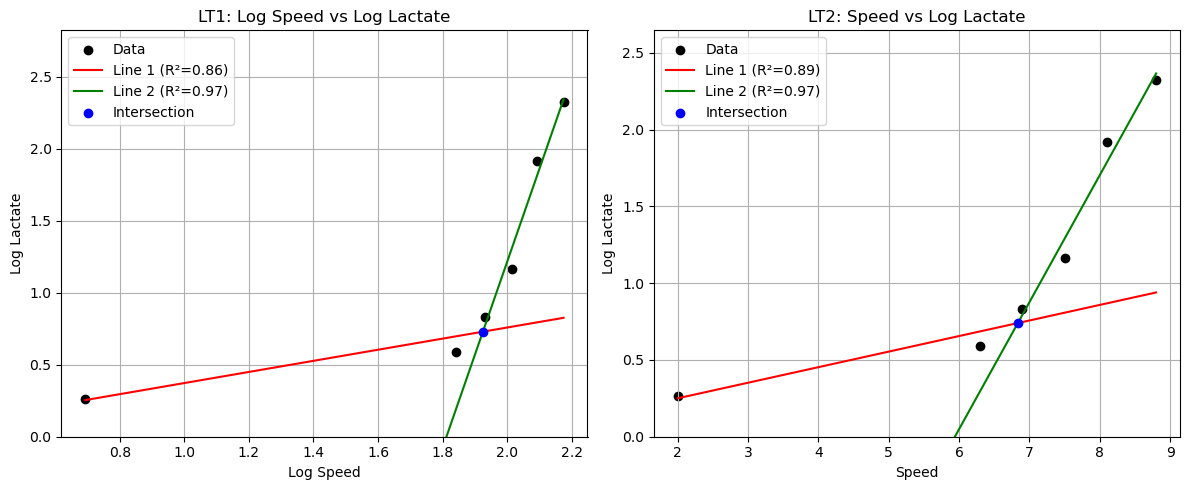

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


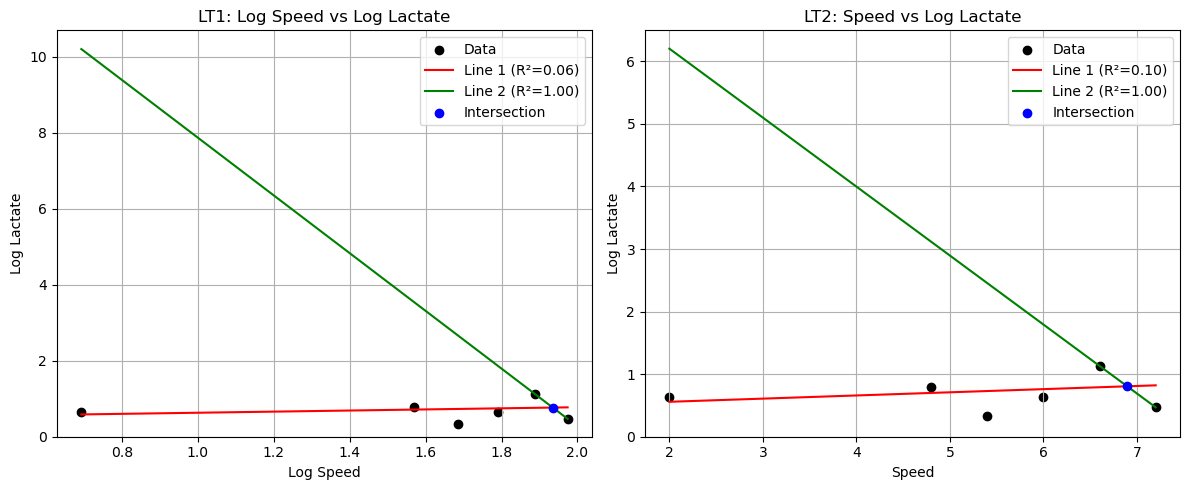

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


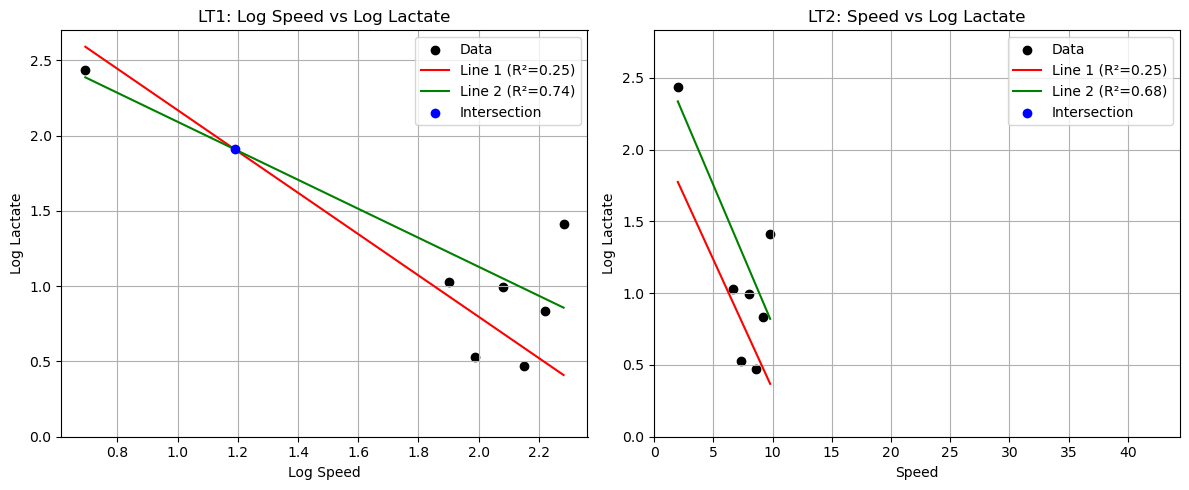

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


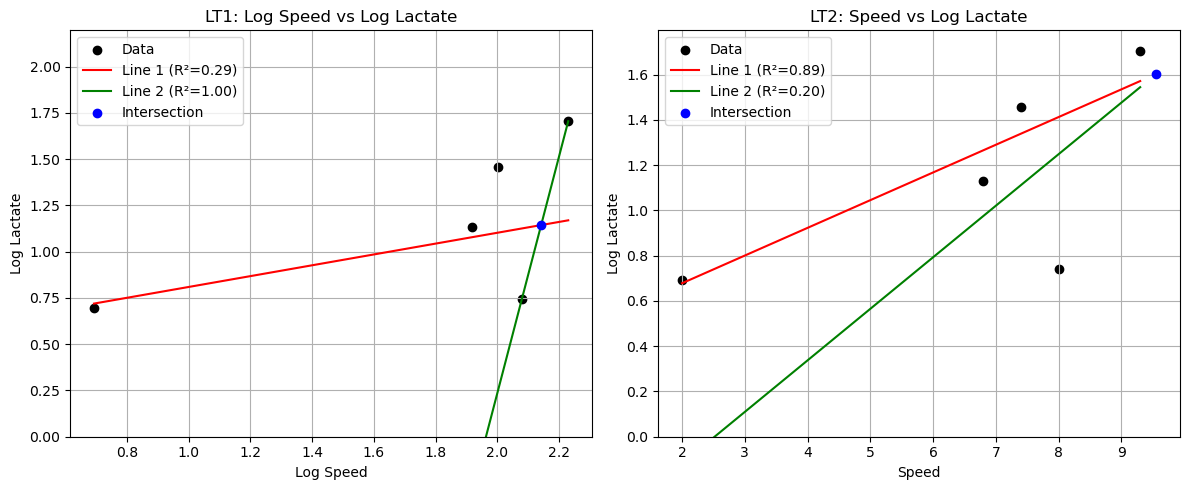

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


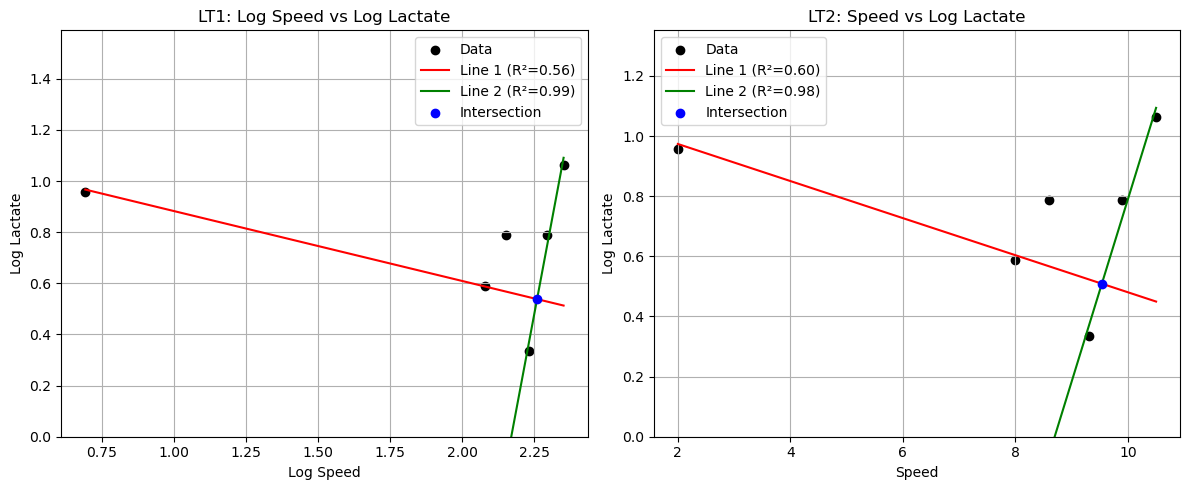

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


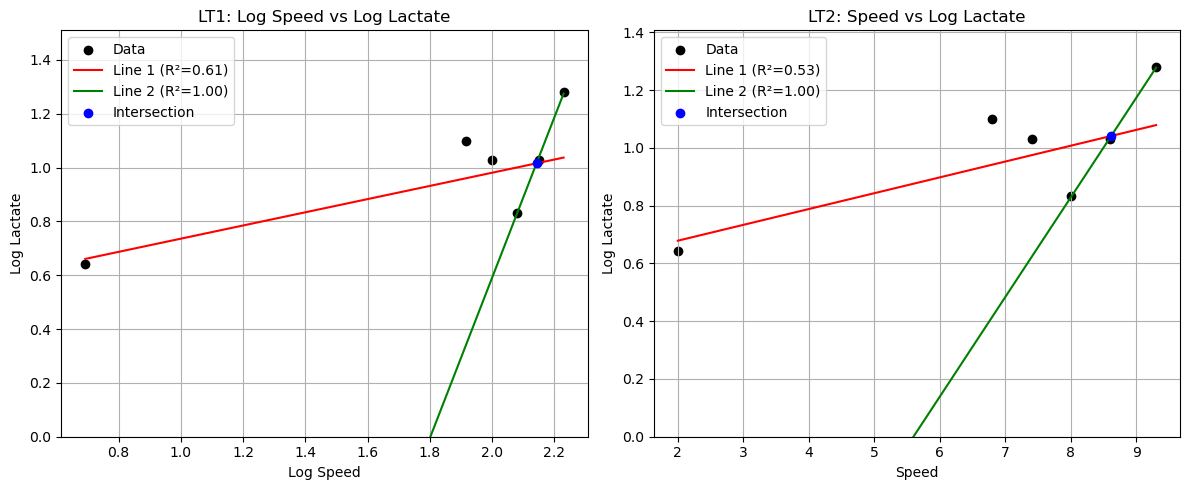

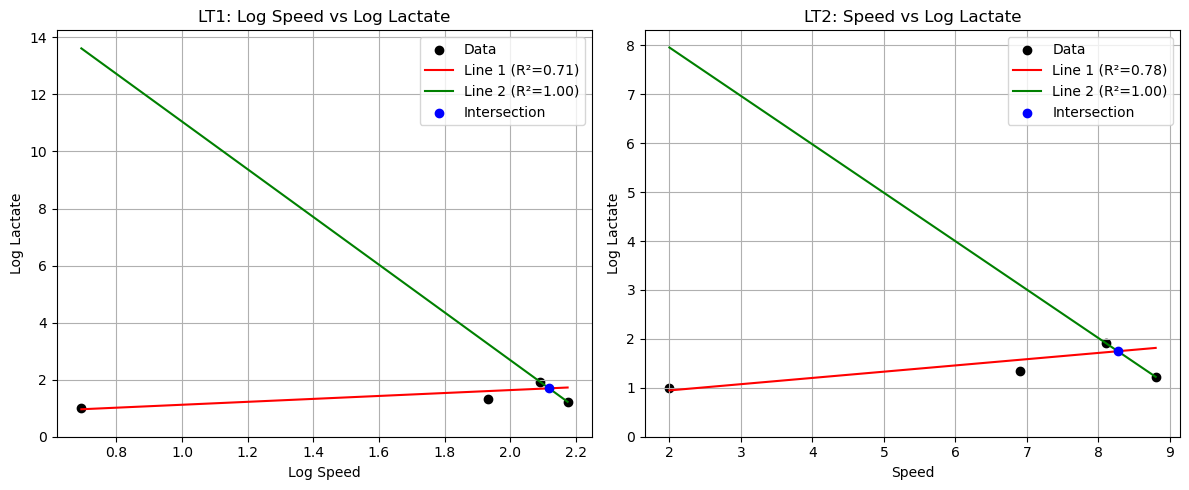

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


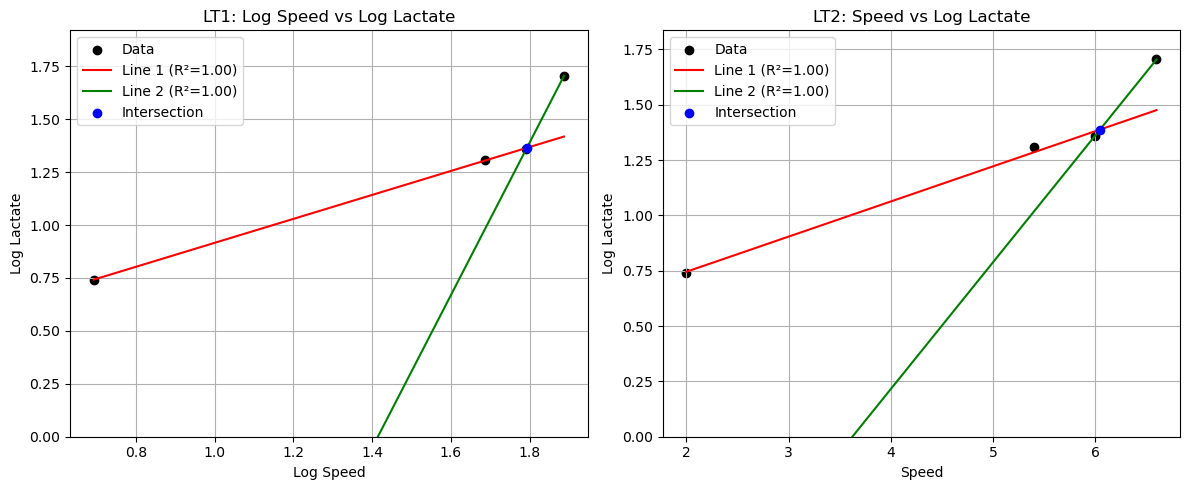

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


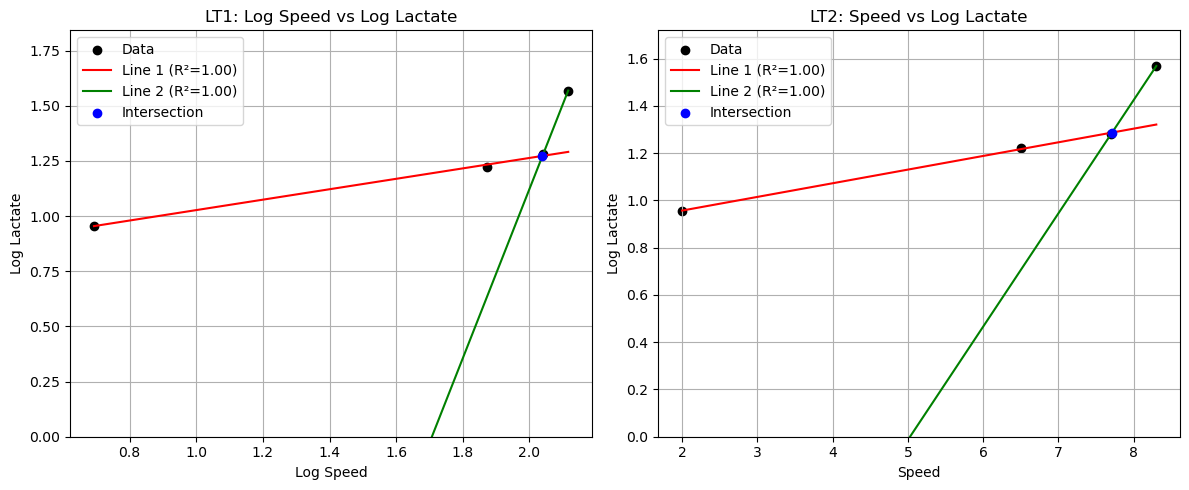

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


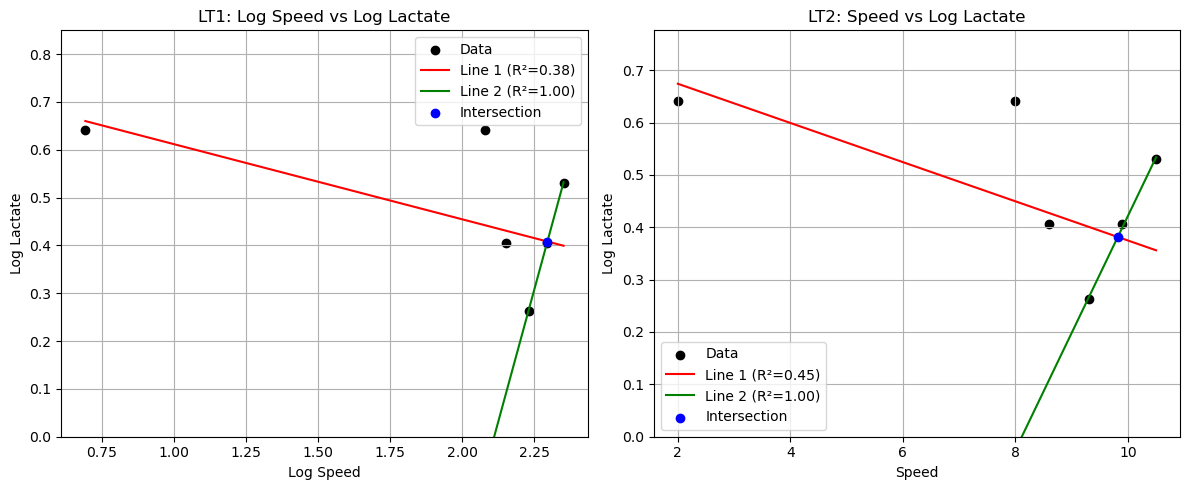

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


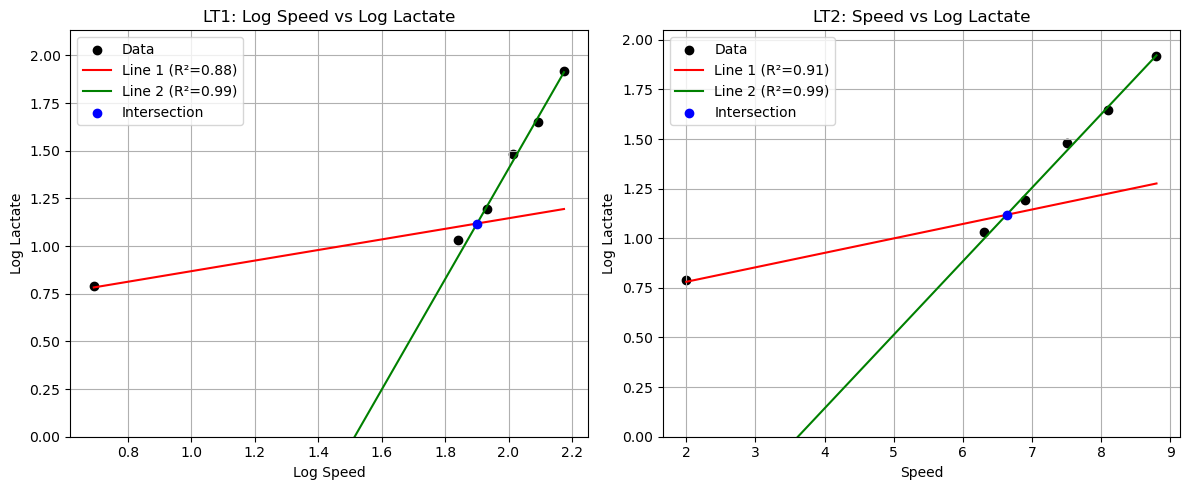

,LT1_ref,LT2_ref,LT1ref_speed,LT2ref_speed,LT1_abs,LT2_abs,LT1abs_speed,LT2abs_speed,LT1_log,LT1_log_speed,LT1_log_r2,LT2_semilog,LT2_semilog_speed,LT2_semi_log_r2
Test Name,,,,,,,,,,,,,,
TR000105_20220207,3.6,3.6,4.8,4.8,2.1,4.7,2.0,6.0,5.574446,7.015555,0.855457,6.863055,6.136242,0.914631
TR000106_20220420,2.4,4.3,7.1,8.3,2.4,4.3,7.1,8.3,1.906243,6.594936,0.949458,6.593568,1.910062,0.952030
TR000102_20220204,4.2,4.2,6.8,6.8,3.2,4.2,2.0,6.8,3.701032,8.985182,0.315441,8.967361,3.806786,0.329163
TR000100_20220623,2.5,5.0,8.6,9.8,2.9,5.0,2.0,9.8,2.003482,8.492251,0.567424,8.407638,1.946956,0.584825
TR000104_20220627,3.2,10.4,8.8,8.8,2.6,10.4,2.0,8.8,2.232814,8.687540,0.501426,8.622199,2.191050,0.533642
TR000100_20220331,2.1,3.5,9.2,9.8,2.1,4.1,2.0,2.0,1.592061,8.415150,0.750100,8.391522,1.559386,0.779775
TR000109_20220209,4.1,4.1,6.9,6.9,3.1,4.1,2.0,6.9,4.487763,7.909333,0.544670,7.936506,4.677765,0.621858
TR000107_20220519,3.5,3.5,8.0,8.0,2.1,7.5,2.0,10.5,2.168712,10.029869,0.360399,9.978255,2.122445,0.358410
TR000106_20220208,3.1,5.8,5.8,6.5,2.6,5.8,2.0,6.5,5.982798,8.063484,0.550467,8.164476,6.641185,0.561781


In [115]:
import pandas as pd
import glob
import os

path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))

results = []
folder_name = "lactate_graphs"

for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_name = test.name  # Assuming each test has a unique name
    test_results = test.lt_ref_vals()
    test_results.update(test.lt_abs_vals())
    if test.lt_log_semilog():
        test_results.update(test.lt_log_semilog(plot=True))
    test_results['Test Name'] = test_name
    
    # Append results to the list
    results.append(test_results)

# Convert results into a DataFrame
results_df = pd.DataFrame(results).set_index('Test Name')

# Display the DataFrame (optional)
results_df

In [116]:
results_df['LT1/LT2_Ref_same'] = results_df['LT1_ref'] == results_df['LT2_ref']
results_df['LT1/LT2_Abs_same'] = results_df['LT1_abs'] == results_df['LT2_abs']
results_df['LT1_Ref_Abs_same'] = results_df['LT1_ref'] == results_df['LT1_abs']
results_df['LT2_Ref_Abs_same'] = results_df['LT2_ref'] == results_df['LT2_abs']
results_df['LT1log_speed>LT2log_speed'] = results_df['LT1_log_speed'] > results_df['LT2_semilog_speed']
results_df['LT1_log>LT2_semilog'] = results_df['LT1_log'] > results_df['LT2_semilog']
results_df = results_df.sort_index()
results_df.sort_values(by='LT1_log_r2', ascending=False)


,LT1_ref,LT2_ref,LT1ref_speed,LT2ref_speed,LT1_abs,LT2_abs,LT1abs_speed,LT2abs_speed,LT1_log,LT1_log_speed,LT1_log_r2,LT2_semilog,LT2_semilog_speed,LT2_semi_log_r2,LT1/LT2_Ref_same,LT1/LT2_Abs_same,LT1_Ref_Abs_same,LT2_Ref_Abs_same,LT1log_speed>LT2log_speed,LT1_log>LT2_semilog
Test Name,,,,,,,,,,,,,,,,,,,,
TR000108_20220209,3.7,3.7,5.4,5.4,2.1,5.5,2.0,6.6,3.915427,6.006571,0.999937,6.047295,4.007126,0.997640,True,False,False,False,True,False
TR000101_20220331,3.4,4.8,6.5,8.3,2.6,4.8,2.0,8.3,3.569491,7.682926,0.998524,7.712744,3.622065,0.999232,False,False,False,True,True,False
TR000110_20220428,2.1,3.3,6.3,7.5,2.1,5.9,6.3,8.1,2.127867,6.922036,0.994310,6.906890,2.144034,0.989008,False,False,True,False,True,False
TR000103_20220204,3.6,3.6,8.0,8.0,2.1,4.2,2.0,8.6,3.911724,8.378838,0.982948,8.381042,3.928585,0.989746,True,False,False,False,True,False
TR000103_20220401,5.9,5.9,9.3,9.3,3.5,5.9,2.0,9.3,2.213647,8.634403,0.973741,8.627891,2.188238,0.982329,True,False,False,True,True,False
TR000106_20220420,2.4,4.3,7.1,8.3,2.4,4.3,7.1,8.3,1.906243,6.594936,0.949458,6.593568,1.910062,0.952030,False,False,True,True,True,False
TR000109_20220824,4.3,4.3,8.8,8.8,2.2,4.3,6.3,8.8,2.382520,8.137912,0.948005,8.159454,2.425536,0.931522,True,False,False,True,True,False
TR000109_20220518,2.8,4.4,6.3,7.5,2.2,4.4,2.0,7.5,3.060430,6.692052,0.946224,6.631433,3.058710,0.956863,False,False,False,True,True,False
TR000110_20220901,1.8,6.8,6.3,8.1,2.3,6.8,6.9,8.1,2.073628,6.853761,0.926557,6.834631,2.096206,0.940022,False,False,False,True,True,False


In [130]:
results_df['LT1_log - LT1 ref'] = results_df['LT1_log'] - results_df['LT1_ref']
results_df['LT2_semilog - LT2 ref'] = results_df['LT2_semilog'] - results_df['LT2_ref']
results_df['LT1_log - LT1_abs'] = results_df['LT1_log'] - results_df['LT1_abs']
results_df['LT2_semilog - LT2_abs'] = results_df['LT2_semilog'] - results_df['LT2_abs']
results_df = results_df[results_df['LT2_semilog'] < 20]
print(abs(results_df['LT1_log - LT1_abs']).describe())
print(abs(results_df['LT2_semilog - LT2_abs']).describe())
#print(abs(results_df['LT1_log - LT1 ref']).describe())
#print(abs(results_df['LT2_semilog - LT2 ref']).describe())

count    30.000000
mean      1.024404
std       0.959331
min       0.027867
25%       0.266281
50%       0.873730
75%       1.401279
max       3.474446
Name: LT1_log - LT1_abs, dtype: float64
count    30.000000
mean      2.708238
std       1.620058
min       0.034631
25%       1.728784
50%       2.329022
75%       4.100645
max       5.648262
Name: LT2_semilog - LT2_abs, dtype: float64


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_57705/4271827488.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['LT1_log - LT1 ref'] = results_df['LT1_log'] - results_df['LT1_ref']
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_57705/4271827488.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['LT2_semilog - LT2 ref'] = results_df['LT2_semilog'] - results_df['LT2_ref']
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_57705/4271827488.py:3: Settin

In [129]:
results_df['LT2_semilog'].sort_values(ascending=False)

Test Name
TR000107_20220519    9.978255
TR000107_20220805    9.819362
TR000103_20220706    9.648262
TR000102_20220401    9.556322
TR000107_20220208    9.536177
TR000102_20220204    8.967361
TR000103_20220401    8.627891
TR000104_20220627    8.622199
TR000102_20220630    8.614629
TR000100_20220623    8.407638
TR000100_20220331    8.391522
TR000103_20220204    8.381042
TR000104_20220314    8.270761
TR000106_20220208    8.164476
TR000109_20220824    8.159454
TR000109_20220209    7.936506
TR000101_20220331    7.712744
TR000106_20220823    7.567625
TR000110_20220210    7.440470
TR000101_20220630    7.071249
TR000110_20220428    6.906890
TR000105_20220920    6.895285
TR000105_20220207    6.863055
TR000110_20220901    6.834631
TR000109_20220518    6.631433
TR000106_20220420    6.593568
TR000105_20220517    6.322675
TR000108_20220209    6.047295
TR000104_20220207    4.826963
TR000101_20220203    0.668274
Name: LT2_semilog, dtype: float64